# Generating Points on the Flag Manifold

## Setup

In [1]:
import flagqmcpy 
import torch
torch.set_default_dtype(torch.float64)
import numpy as np 
import qmcpy as qp
import agsutil
import time
import pandas as pd
import os
import matplotlib
from matplotlib import pyplot
MPLP = agsutil.mpl_setup()
agsutil.print_data_signatures(MPLP,"MPLP",verbose_indent=0)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("torch device = %s"%DEVICE)

MPLP['PW'] = 30
MPLP['FS'] = 30
MPLP['COLORS'] a list of length 10
MPLP['LINESTYLES'] a list of length 10
MPLP['MARKERS'] a list of length 12
torch device = cpu


## Kernel Setup

In [2]:
lam = torch.arange(1,4,device=DEVICE,dtype=float)
lam = lam/torch.linalg.norm(lam)
kernel = flagqmcpy.KernelPolyFlag(lam,r=2,c=1)

## Transform and Generators

In [3]:
def opt_weights(x, eps=1e-12):
    kmat = kernel(x[...,:,None,:,:],x[...,None,:,:,:]) # (...,n,n)
    b = torch.ones(kmat.size(-1),device=DEVICE) # (...,n,)
    L = torch.linalg.cholesky(kmat+eps*torch.eye(kmat.size(-1),device=DEVICE),upper=False) # (...,n,n)
    w = torch.cholesky_solve(b[...,None],L,upper=False)[...,0] # (...,n)
    return w
def genflag_qr_iid_x_opt_w(n, lam, seed=None):
    x = flagqmcpy.genflag_x_qr_iid(n,lam,seed)
    w = opt_weights(x)
    return x,w
def genflag_qr_ld_x_opt_w(n, lam, seed=None):
    x = flagqmcpy.genflag_x_qr_ld(n,lam,seed)
    w = opt_weights(x)
    return x,w
def genflag_eig_iid_x_opt_w(n, lam, seed=None):
    x = flagqmcpy.genflag_x_eig_iid(n,lam,seed)
    w = opt_weights(x)
    return x,w
def genflag_eig_ld_x_opt_w(n, lam, seed=None):
    x = flagqmcpy.genflag_x_eig_ld(n,lam,seed)
    w = opt_weights(x)
    return x,w

## Optimized Points and Weights

In [4]:
def genf_opt_x_w(
        n,
        lam,
        seed=None,
        verbose = False, 
        iters = 100,
        eps_kmat = 1e-8,
        verbose_indent = 4,
        ):
    t = lam.size(-1)
    u = torch.from_numpy(qp.DigitalNetB2(t**2,seed=seed,randomize="LMS_DS",order="GRAY")(n)).to(DEVICE)
    theta0 = flagqmcpy.tff_qr(u)
    zerosn = torch.zeros(n,device=DEVICE)
    onesn = torch.ones(n,device=DEVICE)
    eyen = torch.eye(n,device=DEVICE)
    def discrepancy_loss(theta):
        q = agsutil.to_unitary_qr(theta)
        x = torch.einsum("...ij,...j,...kj->...ik",q,lam,q)
        kmat = kernel(x[...,:,None,:,:],x[...,None,:,:,:]) # (n,n)
        L = torch.linalg.cholesky(kmat+eps_kmat*eyen,upper=False) # (n,n)
        v = torch.linalg.solve_triangular(L,onesn[...,None],upper=False)[...,0]
        # discrep = 1-(v**2).sum(-1)
        return v,x,L
    u,x,L = agsutil.lm_opt(
        f = discrepancy_loss,
        theta0 = theta0,
        ytrue = zerosn,
        iters = iters,
        verbose = verbose,
        verbose_indent = verbose_indent,
        loss_mult = -1,
        loss_shift = 1,
        # store_data_iters = True,
    )
    # print(data["losses_quantiles"]["50"])
    # print(data["losses_quantiles"]["50"][1:]-data["losses_quantiles"]["50"][:-1])
    w = torch.cholesky_solve(onesn[...,None],L,upper=False)[...,0]
    return x,w

genf_opt_x_w(
    n = 2**3, 
    lam=lam,
    seed = 17,
    verbose = None);

    iter i     | losses_quantiles                                          | lams_quantiles                                            | alphas_quantiles                                          | times     
               | 5         | 25        | 50        | 75        | 90        | 5         | 25        | 50        | 75        | 90        | 5         | 25        | 50        | 75        | 90        |           
    ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
    0          | 3.6e-03   | 3.6e-03   | 3.6e-03   | 3.6e-03   | 3.6e-03   | 1.0e-06   | 1.0e-06   | 1.0e-06   | 1.0e-06   | 1.0e-06   | 1.0e+00   | 1.0e+00   | 1.0e+00   | 1.0e+00   | 1.0e+00   | 0.2        
    5          | 4.9e-04   | 4.9e-04   | 4.9e-04   | 4.9e-04   | 4.9e-04   | 3.2e-05   | 3.2e-05   | 3.2e-05   | 3.2e-05   | 3.2e-05   | 6.2e-02   | 6.2e-02   | 6.2e-0

## Convergence on a Test Function

In [5]:
def discrepancy(x, w, return_kmat=False):
    assert x.ndim>=2
    assert x.size(-3)==w.size(-1)
    kmat = kernel(x[...,:,None,:,:],x[...,None,:,:,:]) # (...,n,n)
    discrep = torch.einsum("...i,...ij,...j->...",w,kmat,w)-2*w.sum()+1 # (...,)
    if return_kmat:
        return discrep,kmat 
    else:
        return discrep

In [6]:
genf_funcs = [
    [r"QR IID $x$ ~ Equal $w$", flagqmcpy.genflag_x_qr_iid_equal_w], 
    [r"QR LD $x$ ~ Equal $w$", flagqmcpy.genflag_x_qr_ld_equal_w], 
    [r"QR IID $x$ ~ Opt $w$", genflag_qr_iid_x_opt_w], 
    [r"QR LD $x$ ~ Opt $w$", genflag_qr_ld_x_opt_w], 
    [r"Eig IID $x$ ~ Equal $w$", flagqmcpy.genflag_x_eig_iid_equal_w], 
    [r"Eig LD $x$ ~ Equal $w$", flagqmcpy.genflag_x_eig_ld_equal_w], 
    [r"Eig IID $x$ ~ Opt $w$", genflag_eig_iid_x_opt_w], 
    [r"Eig LD $x$ ~ Opt $w$", genflag_eig_ld_x_opt_w], 
    
]
n = 2**torch.arange(2,12)
trials = 5
seeds = [i for i in range(trials)]
discreps = torch.empty((len(genf_funcs),len(n),trials))
t0 = time.perf_counter()
cond = np.nan
for i,(key,genf_func) in enumerate(genf_funcs):
    print(key)
    for j in range(len(n)):
        print("    n = %d"%n[j])
        for t in range(trials):
            x,w = genf_func(n=n[j],lam=lam,seed=seeds[t])
            discreps[i,j,t] = float(discrepancy(x,w).cpu())
            # cond = torch.linalg.cond(kernel(x[...,:,None,:,:],x[...,None,:,:,:],lam,r,c)+1e-8*torch.eye(n[j],device=DEVICE))
            print("        trial %-10d time %-10.1f discrep %-10.1e Kmat_cond %-10.1e"%(t,time.perf_counter()-t0,discreps[i,j,t],cond))

QR IID $x$ ~ Equal $w$
    n = 4
        trial 0          time 0.0        discrep 7.0e-02    Kmat_cond nan       
        trial 1          time 0.0        discrep 7.7e-03    Kmat_cond nan       
        trial 2          time 0.0        discrep 3.8e-02    Kmat_cond nan       
        trial 3          time 0.0        discrep 1.5e-02    Kmat_cond nan       
        trial 4          time 0.0        discrep 3.0e-02    Kmat_cond nan       
    n = 8
        trial 0          time 0.0        discrep 1.9e-02    Kmat_cond nan       
        trial 1          time 0.0        discrep 2.0e-02    Kmat_cond nan       
        trial 2          time 0.0        discrep 4.4e-02    Kmat_cond nan       
        trial 3          time 0.0        discrep 1.0e-02    Kmat_cond nan       
        trial 4          time 0.0        discrep 2.4e-02    Kmat_cond nan       
    n = 16
        trial 0          time 0.0        discrep 7.5e-03    Kmat_cond nan       
        trial 1          time 0.0        discrep 1.7e-0

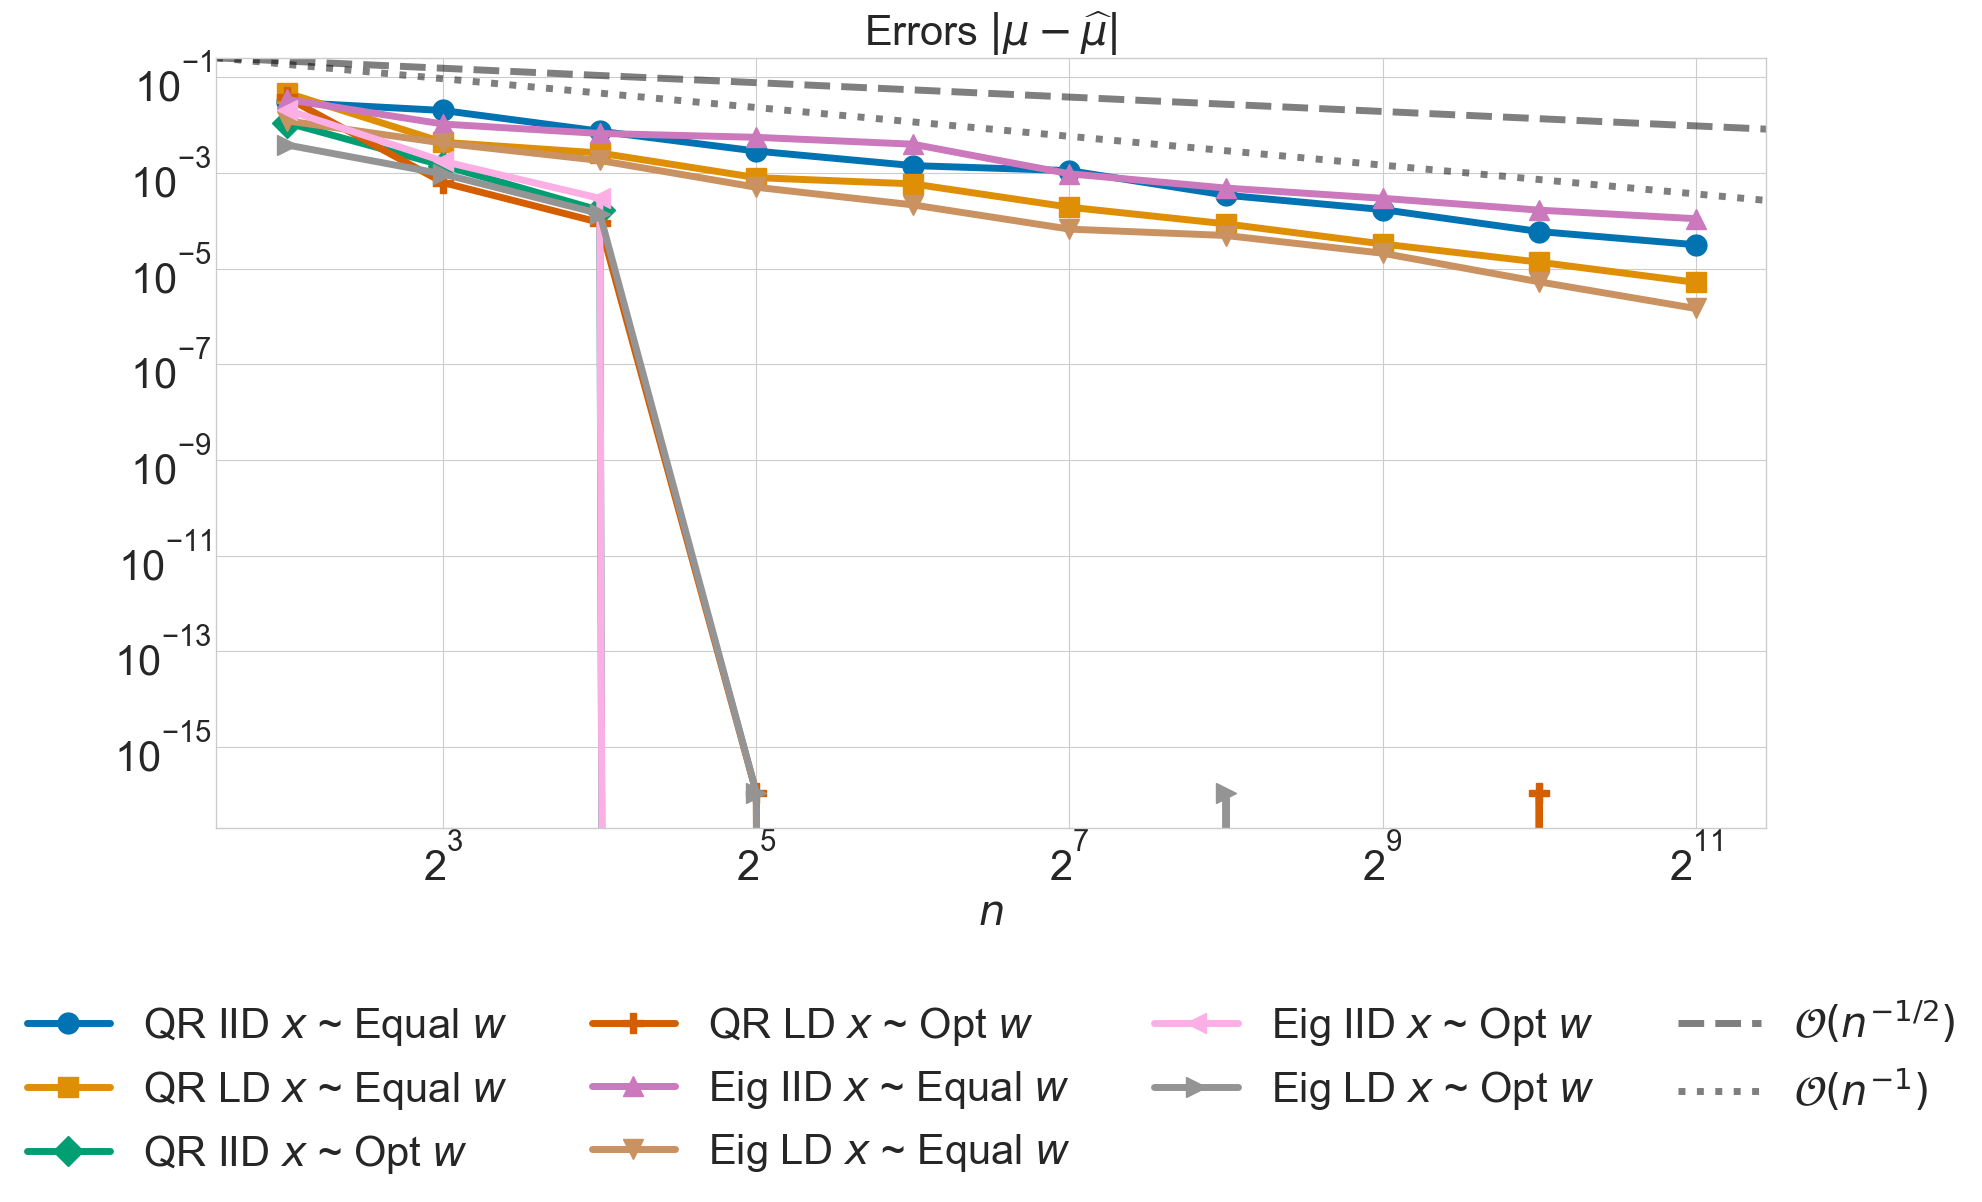

In [7]:
fig,ax = pyplot.subplots(nrows=1,ncols=1,figsize=(MPLP["PW"]/1.5,MPLP["PW"]/2/1.5),sharex=True,sharey=False)
for i,(key,_) in enumerate(genf_funcs):
    ax.plot(n,discreps[i].median(-1).values,color=MPLP["COLORS"][i],marker=MPLP["MARKERS"][i],label=key)
ax.set_yscale("log",base=10)
ax.set_xscale("log",base=2)
xmin,xmax = ax.get_xlim()
ymin,ymax = ax.get_ylim()
ax.set_xlim([xmin,xmax])
ax.set_ylim([ymin,ymax])
ax.axline([xmin,ymax],[2*xmin,2**(-1/2)*ymax],color="k",alpha=0.5,label=r"$\mathcal{O}(n^{-1/2})$",linestyle="dashed")
ax.axline([xmin,ymax],[2*xmin,2**(-1)*ymax],color="k",alpha=0.5,label=r"$\mathcal{O}(n^{-1})$",linestyle="dotted")
ax.legend(frameon=False,ncols=4,loc="lower center",bbox_to_anchor=(.5,-.5))
ax.set_title(r"Errors $|\mu - \widehat{\mu}|$")
ax.set_xlabel(r"$n$");

In [8]:
discreps_df = pd.DataFrame(discreps.median(-1).values.T,columns=[name for (name,_) in genf_funcs])
discreps_df['n'] = n
discreps_df.set_index('n')
print(r"Discrep")
discreps_df


Discrep


,QR IID $x$ ~ Equal $w$,QR LD $x$ ~ Equal $w$,QR IID $x$ ~ Opt $w$,QR LD $x$ ~ Opt $w$,Eig IID $x$ ~ Equal $w$,Eig LD $x$ ~ Equal $w$,Eig IID $x$ ~ Opt $w$,Eig LD $x$ ~ Opt $w$,n
0,0.030362,0.047490,1.127564e-02,3.801140e-02,0.034603,0.012383,2.099263e-02,3.877723e-03,4
1,0.020300,0.004397,1.430355e-03,6.318197e-04,0.010568,0.004225,1.759297e-03,9.522959e-04,8
2,0.007498,0.002625,1.656646e-04,9.253650e-05,0.006722,0.001831,2.963613e-04,1.417664e-04,16
3,0.002878,0.000802,0.000000e+00,1.110223e-16,0.005583,0.000505,0.000000e+00,1.110223e-16,32
4,0.001431,0.000594,0.000000e+00,-2.220446e-16,0.004008,0.000216,-2.220446e-16,-2.220446e-16,64
5,0.001122,0.000193,0.000000e+00,0.000000e+00,0.000965,0.000067,-2.220446e-16,0.000000e+00,128
6,0.000345,0.000087,-2.220446e-16,-4.440892e-16,0.000485,0.000049,-4.440892e-16,1.110223e-16,256
7,0.000172,0.000033,0.000000e+00,0.000000e+00,0.000297,0.000021,0.000000e+00,-2.220446e-16,512
8,0.000060,0.000014,0.000000e+00,1.110223e-16,0.000168,0.000005,-4.440892e-16,0.000000e+00,1024
9,0.000032,0.000005,-2.220446e-16,-2.220446e-16,0.000111,0.000001,-4.440892e-16,-4.440892e-16,2048
